# K-Means Clustering – Developer Servey Skill Profiling

**Goal:** Group developer answer records into clusters based on binary skill requirements,  
then compare each cluster's skill profile against developer job type.

**Data:** `prepared_survey_data.csv` — 49,191 records with 83 binary skill indicators.

## 0 · Packages and Data Loading

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
import numpy as np
# Load the dataset
df = pd.read_csv('data/prepared_survey_data.csv')
print(f'Shape : {df.shape}')

Shape : (49191, 85)


## 1 · Explore Data

In [2]:
# Identify columns 
META_COLS  = ["DevType", "Industry"]
SKILL_COLS = df.columns[2:].tolist()
 
print(f"\n  Metadata cols  : {META_COLS}")
print(f"  Skill cols     : {len(SKILL_COLS)} features")
print(f"  Job role dist  :\n{df['DevType'].value_counts().head(10).to_string()}")


  Metadata cols  : ['DevType', 'Industry']
  Skill cols     : 83 features
  Job role dist  :
DevType
Developer, full-stack                            12351
Developer, back-end                               6453
Student                                           3008
Architect, software or solutions                  2684
Developer, front-end                              1974
Developer, desktop or enterprise applications     1919
Other (please specify):                           1825
Developer, mobile                                 1391
Developer, embedded applications or devices       1274
Academic researcher                               1131


In [3]:
# Data Cleaning & Preparation
df_clean = df.dropna(subset=['DevType']).copy()

# Select only the binary skill indicator columns (starting from index 2)
skill_cols = df_clean.columns[2:]
X = df_clean[skill_cols]

## 2 · Optimal K Selection

In [4]:
from sklearn.metrics import silhouette_score
within_sse = []
sil = []
k_values = range(2,11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=617)
    kmeans.fit(X)
    within_sse.append(kmeans.inertia_)
    sil.append(silhouette_score(X, labels = kmeans.fit_predict(X)))

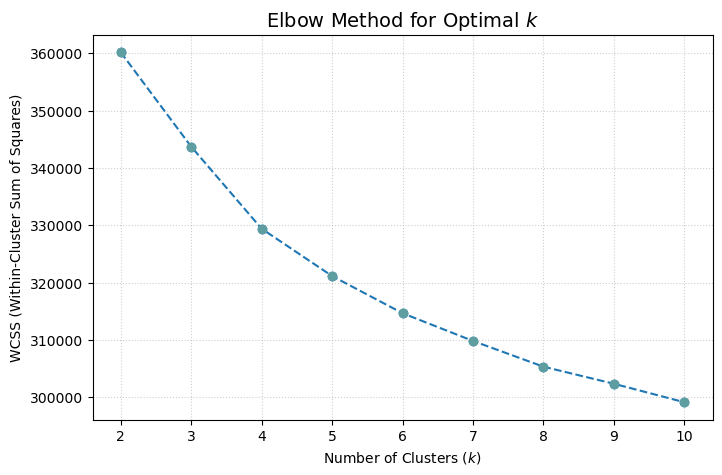

In [5]:
# Visualization of the Elbow Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_values, within_sse, c='cadetblue', zorder=3)
ax.plot(k_values, within_sse, marker='o', linestyle='--', zorder=2)
ax.set_title('Elbow Method for Optimal $k$', fontsize=14)
ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
ax.grid(True, linestyle=':', alpha=0.6, zorder=1)
plt.savefig('elbow_plot_survey.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

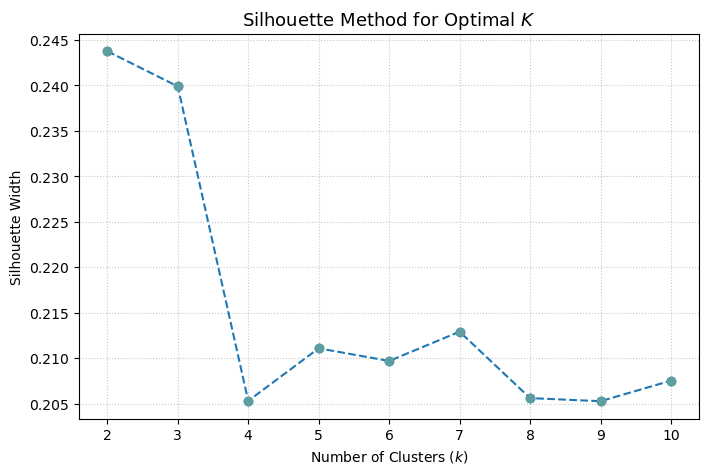

In [6]:
# Visualization of the Silhouette Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_values, sil, c='cadetblue', zorder=3)
ax.plot(k_values, sil, marker='o', linestyle='--', zorder=2)
ax.set_title('Silhouette Method for Optimal $K$', fontsize=13)
ax.set_xlabel('Number of Clusters ($k$)')
ax.set_ylabel('Silhouette Width')
ax.grid(True, linestyle=':', alpha=0.7, zorder=1)
plt.savefig('sil_plot_survey.png', transparent=True, dpi=300, bbox_inches='tight')
plt.show()

## 3 · Final KMeans Model

In [14]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=617, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X)

In [15]:
# Cluster Profiling Logic
cluster_profiles = []

for i in range(k_optimal):
    cluster_data = df_clean[df_clean['Cluster'] == i]
    
    #skill frequency as a percentage
    skill_freq = cluster_data[skill_cols].mean().sort_values(ascending=False).head(10)
    
    #top job titles in this cluster
    top_titles = cluster_data['DevType'].value_counts().head(5)
    
    cluster_profiles.append({
        'Cluster': i,
        'Size': len(cluster_data),
        'Top Skills': skill_freq.to_dict(),
        'Top Titles': top_titles.to_dict()
    })


In [16]:
# Visualization Preparation
summary_list = []
for p in cluster_profiles:
    for skill, freq in p['Top Skills'].items():
        summary_list.append({'Cluster': p['Cluster'], 'Name': skill, 'Value': freq})

df_summary = pd.DataFrame(summary_list)

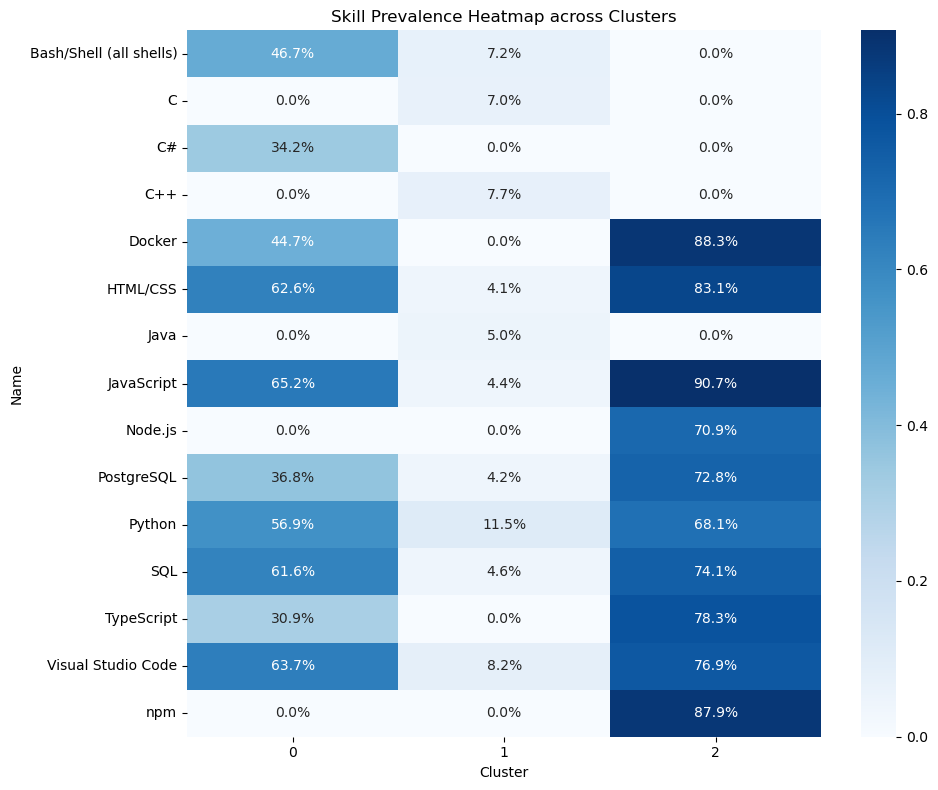

In [17]:
# VISUAL 1: Skill Prevalence Heatmap
skill_matrix = df_summary.pivot(index='Name', columns='Cluster', values='Value').fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(skill_matrix, annot=True, cmap='Blues', fmt='.1%')
plt.title('Skill Prevalence Heatmap across Clusters')
plt.tight_layout()
plt.savefig('skill_prevalence_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

In [18]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=617, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X)

In [19]:
# Cluster Profiling Logic
cluster_profiles = []

for i in range(k_optimal):
    cluster_data = df_clean[df_clean['Cluster'] == i]
    
    #skill frequency as a percentage
    skill_freq = cluster_data[skill_cols].mean().sort_values(ascending=False).head(10)
    
    #top job titles in this cluster
    top_titles = cluster_data['DevType'].value_counts().head(5)
    
    cluster_profiles.append({
        'Cluster': i,
        'Size': len(cluster_data),
        'Top Skills': skill_freq.to_dict(),
        'Top Titles': top_titles.to_dict()
    })


In [20]:
# Visualization Preparation
summary_list = []
for p in cluster_profiles:
    for skill, freq in p['Top Skills'].items():
        summary_list.append({'Cluster': p['Cluster'], 'Name': skill, 'Value': freq})

df_summary = pd.DataFrame(summary_list)

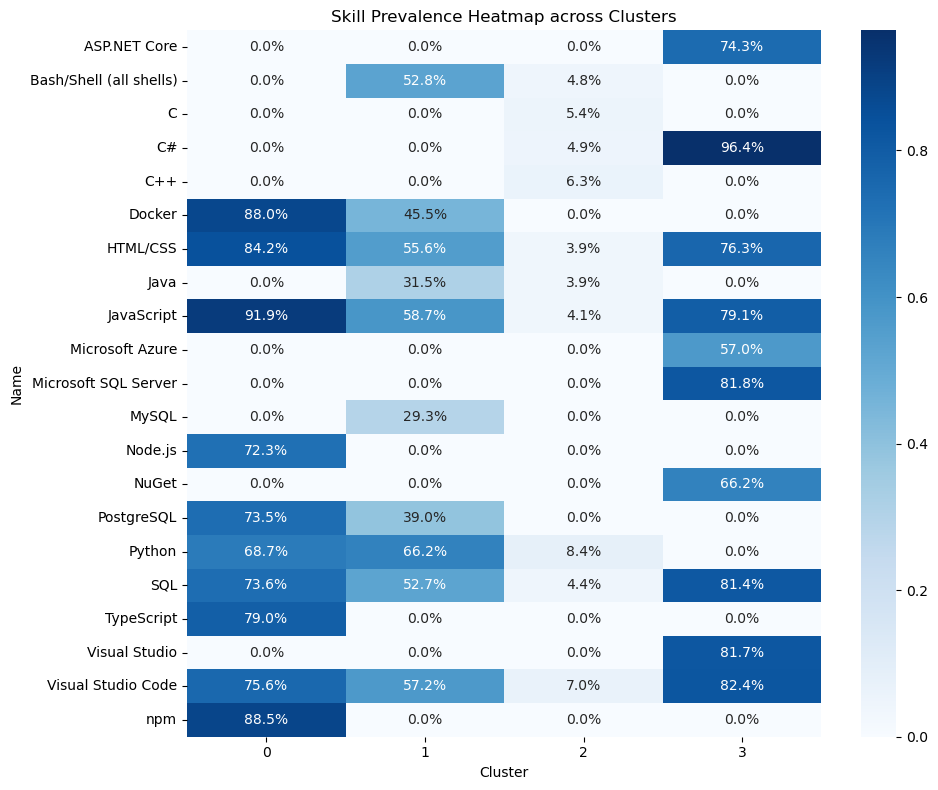

In [21]:
# VISUAL 1: Skill Prevalence Heatmap
skill_matrix = df_summary.pivot(index='Name', columns='Cluster', values='Value').fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(skill_matrix, annot=True, cmap='Blues', fmt='.1%')
plt.title('Skill Prevalence Heatmap across Clusters')
plt.tight_layout()
plt.savefig('skill_prevalence_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

In [22]:
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=617, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X)

In [23]:
# Cluster Profiling Logic
cluster_profiles = []

for i in range(k_optimal):
    cluster_data = df_clean[df_clean['Cluster'] == i]
    
    #skill frequency as a percentage
    skill_freq = cluster_data[skill_cols].mean().sort_values(ascending=False).head(10)
    
    #top job titles in this cluster
    top_titles = cluster_data['DevType'].value_counts().head(5)
    
    cluster_profiles.append({
        'Cluster': i,
        'Size': len(cluster_data),
        'Top Skills': skill_freq.to_dict(),
        'Top Titles': top_titles.to_dict()
    })


In [24]:
# Visualization Preparation
summary_list = []
for p in cluster_profiles:
    for skill, freq in p['Top Skills'].items():
        summary_list.append({'Cluster': p['Cluster'], 'Name': skill, 'Value': freq})

df_summary = pd.DataFrame(summary_list)

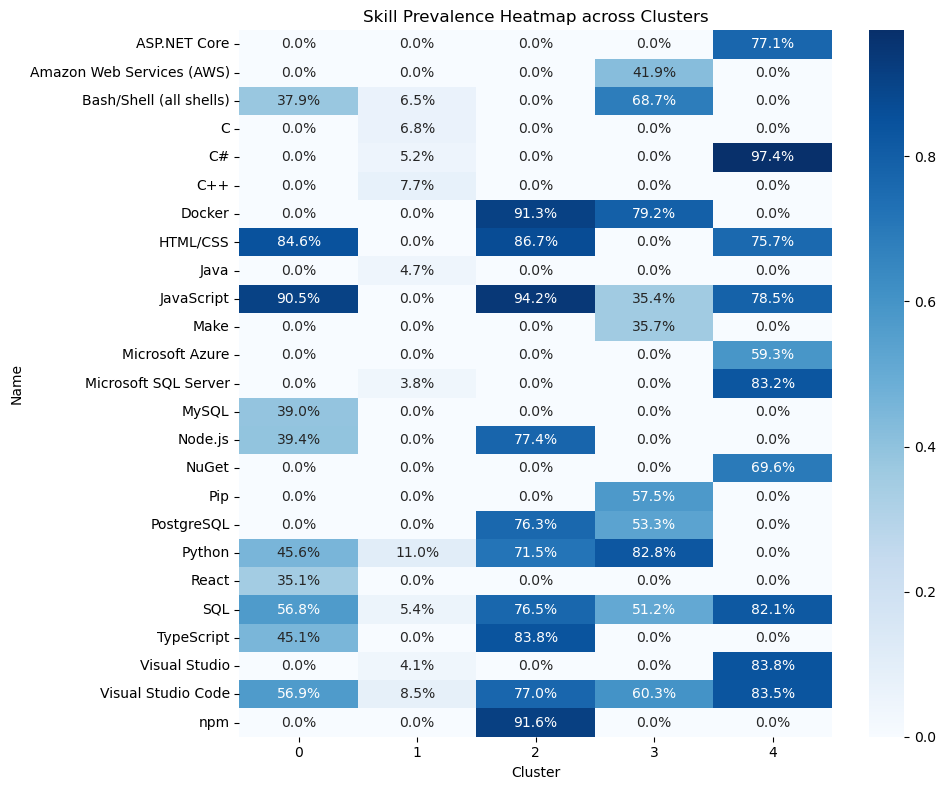

In [25]:
# VISUAL 1: Skill Prevalence Heatmap
skill_matrix = df_summary.pivot(index='Name', columns='Cluster', values='Value').fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(skill_matrix, annot=True, cmap='Blues', fmt='.1%')
plt.title('Skill Prevalence Heatmap across Clusters')
plt.tight_layout()
plt.savefig('skill_prevalence_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

In [26]:
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=617, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X)

In [27]:
# Cluster Profiling Logic
cluster_profiles = []

for i in range(k_optimal):
    cluster_data = df_clean[df_clean['Cluster'] == i]
    
    #skill frequency as a percentage
    skill_freq = cluster_data[skill_cols].mean().sort_values(ascending=False).head(10)
    
    #top job titles in this cluster
    top_titles = cluster_data['DevType'].value_counts().head(5)
    
    cluster_profiles.append({
        'Cluster': i,
        'Size': len(cluster_data),
        'Top Skills': skill_freq.to_dict(),
        'Top Titles': top_titles.to_dict()
    })


## 4 · Visualizations

In [28]:
# Visualization Preparation
summary_list = []
for p in cluster_profiles:
    for skill, freq in p['Top Skills'].items():
        summary_list.append({'Cluster': p['Cluster'], 'Name': skill, 'Value': freq})

df_summary = pd.DataFrame(summary_list)

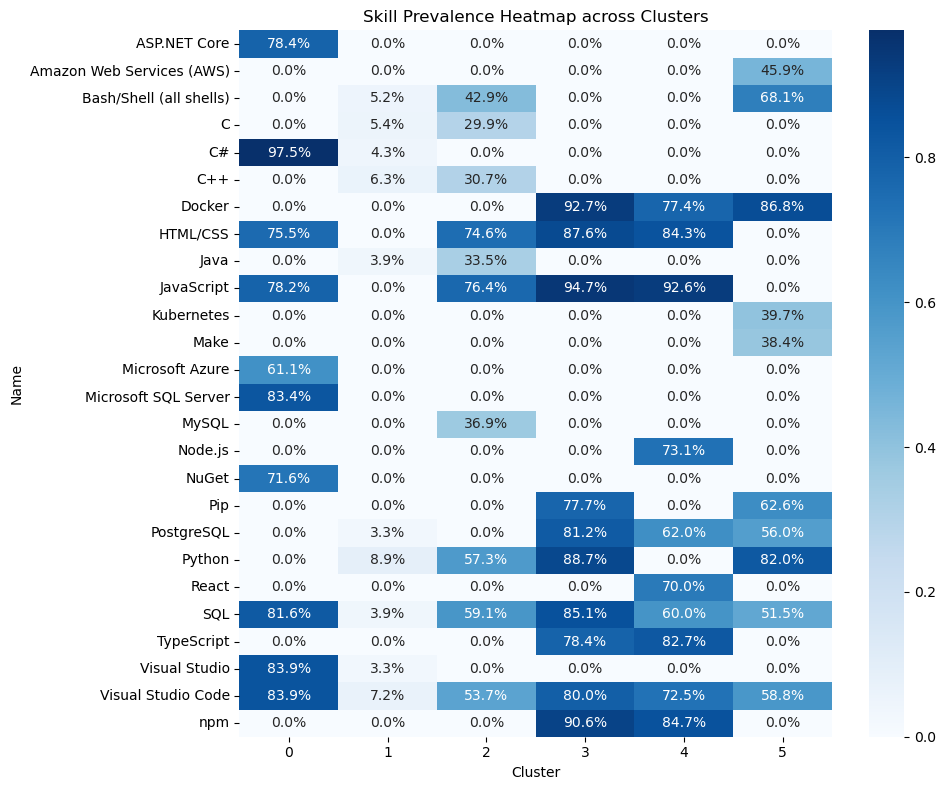

In [29]:
# VISUAL 1: Skill Prevalence Heatmap
skill_matrix = df_summary.pivot(index='Name', columns='Cluster', values='Value').fillna(0)
plt.figure(figsize=(10, 8))
sns.heatmap(skill_matrix, annot=True, cmap='Blues', fmt='.1%')
plt.title('Skill Prevalence Heatmap across Clusters')
plt.tight_layout()
plt.savefig('skill_prevalence_heatmap.png', transparent=True, dpi=300, bbox_inches='tight')

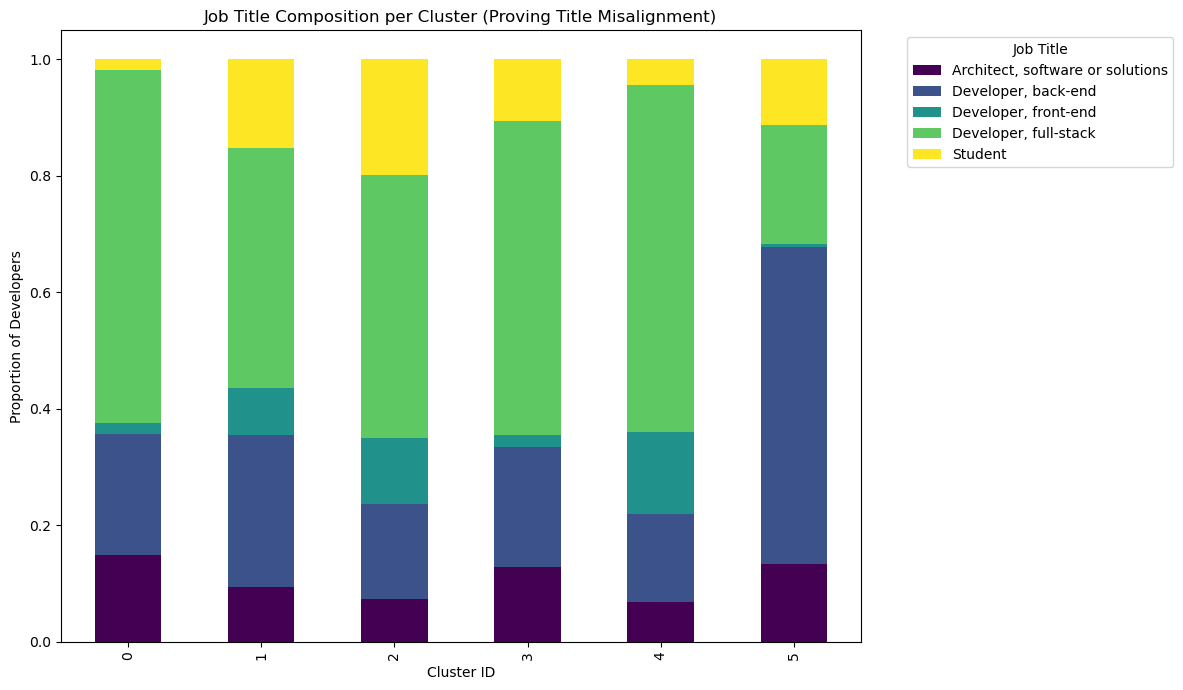

In [11]:
# VISUAL 2: Job Title Composition (Proving Title Misalignment)
top_titles_list = df_clean['DevType'].value_counts().head(5).index
df_filtered = df_clean[df_clean['DevType'].isin(top_titles_list)]
title_composition = pd.crosstab(df_filtered['Cluster'], df_filtered['DevType'], normalize='index')

title_composition.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Job Title Composition per Cluster (Proving Title Misalignment)')
plt.ylabel('Proportion of Developers')
plt.xlabel('Cluster ID')
plt.legend(title='Job Title', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('job_title_misalignment.png')

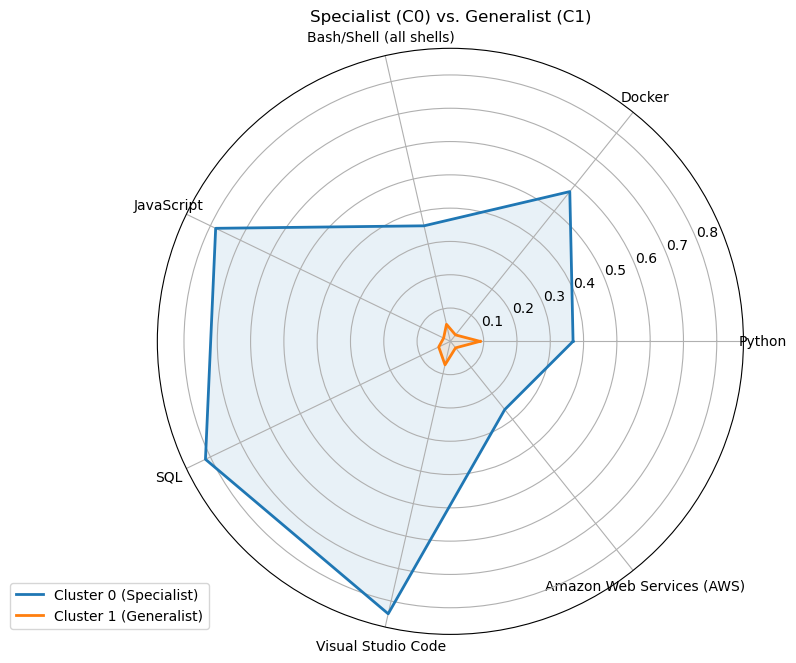

In [34]:
# VISUAL 3: Radar Chart (Specialist vs Generalist) ---
radar_skills = [
    'Python',
    'Docker',
    'Bash/Shell (all shells)',
    'JavaScript',
    'SQL',
    'Visual Studio Code',
    'Amazon Web Services (AWS)',
]

cluster_means = df_clean.groupby('Cluster')[skill_cols].mean()
radar_data = cluster_means[radar_skills].loc[[0, 1]]

categories = radar_skills
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Cluster 0
values_c0 = radar_data.loc[0].values.flatten().tolist()
values_c0 += values_c0[:1]
ax.plot(angles, values_c0, linewidth=2, label='Cluster 0 (Specialist)')
ax.fill(angles, values_c0, alpha=0.1)

# Cluster 1
values_c1 = radar_data.loc[1].values.flatten().tolist()
values_c1 += values_c1[:1]
ax.plot(angles, values_c1, linewidth=2, label='Cluster 1 (Generalist)')
ax.fill(angles, values_c1, alpha=0.1)

plt.xticks(angles[:-1], categories)
plt.title('Specialist (C0) vs. Generalist (C1)')
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.tight_layout()
plt.savefig('specialist_vs_generalist_radar.png')

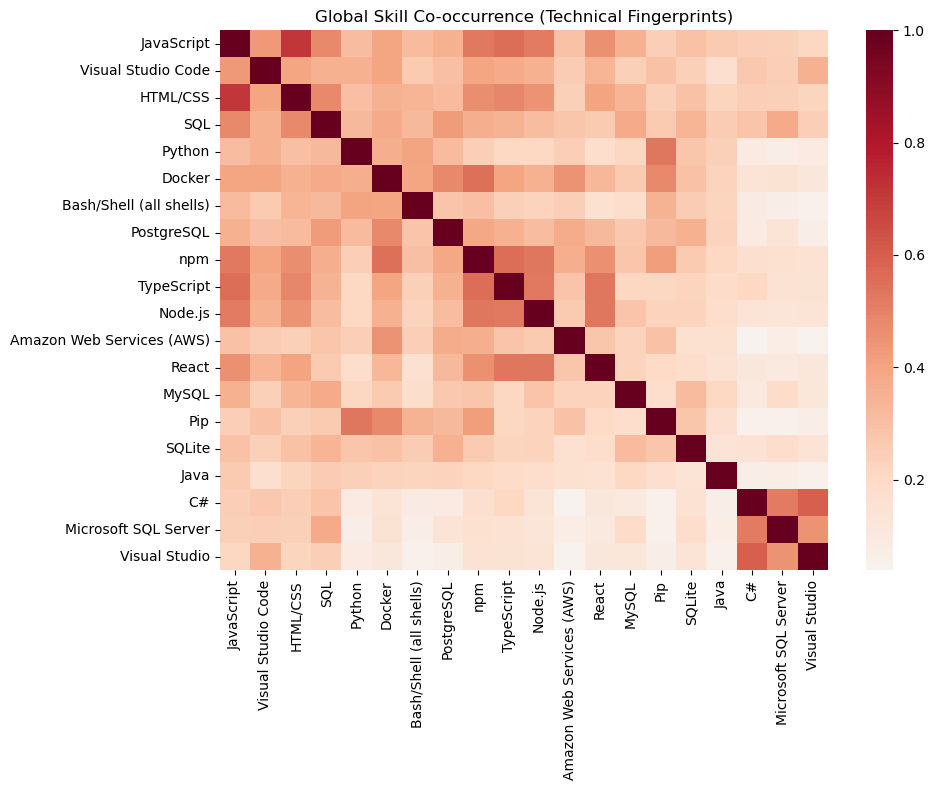

In [30]:
# VISUAL 4: Global Skill Correlation (The Fingerprints) ---
top_20_skills = df_clean[skill_cols].mean().sort_values(ascending=False).head(20).index
skill_corr = df_clean[top_20_skills].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(skill_corr, cmap='RdBu_r', center=0)
plt.title('Global Skill Co-occurrence (Technical Fingerprints)')
plt.tight_layout()
plt.savefig('skill_correlation_fingerprints.png')

## 5 · Export Summary Data

In [ ]:
# Export the summary data
df_summary.to_csv('data/final_cluster_summary.csv', index=False)